# <span style="color: turquoise;">Модель для предсказания массы морских черепах</span>

##  <span style="color: turquoise;">Постановка задачи</span>

### Какую задачу нужно решить
В данном проекте необходимо решить задачу **регрессии**, поскольку требуется предсказывать **числовое значение массы черепахи** на основе её измеряемых признаков.

### Целевая переменная
Целевой переменной будет поле **`weight`**, так как именно оно содержит массу черепахи в килограммах, которую должна предсказывать модель.

### Метрики качества модели
Для оценки качества модели планируется использовать следующие метрики:

- **MAE (Mean Absolute Error)** — средняя абсолютная ошибка. Показывает, на сколько килограммов в среднем предсказание отличается от реального значения массы.
- **MAPE (Mean Absolute Percentage Error)** — средняя абсолютная процентная ошибка. Позволяет оценить ошибку в относительном выражении, что особенно важно, поскольку модель должна работать для черепах разного возраста и размера.
- **R² (коэффициент детерминации)** — показывает, какую долю вариативности целевой переменной объясняет модель.

### Критерии успешности проекта
Проект можно считать успешным, если выбранная линейная модель на валидационной и тестовой выборках показывает результаты, удовлетворяющие требованиям заказчика:

- значение **MAE** для взрослых особей должно быть **не более 5 кг**;
- значение **R²** должно быть **не ниже 0.97**;
- значение **MAPE** должно оставаться низким, чтобы модель демонстрировала хорошее качество предсказаний не только в абсолютных, но и в относительных величинах.

Таким образом, успешной будет считаться модель линейной регрессии, которая обеспечивает малую абсолютную и относительную ошибку и при этом объясняет большую часть изменчивости массы черепах.

## Подключение и настройка библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error

In [2]:
# Константы

RANDOM_STATE = 42

## Загрузка датасета

In [3]:
df = pd.read_csv('/datasets/turtles.csv', sep='\t', decimal=',')

#df = pd.read_csv('turtles.csv', sep='\t', decimal=',')

In [4]:
print('Размер таблицы:', df.shape)
print()
print('Названия столбцов:')
print(df.columns.tolist())
print()
print('Первые 5 строк:')
display(df.head())
print()
print('Общая информация:')
df.info()
print()
print('Пропуски по столбцам:')
print(df.isna().sum())

Размер таблицы: (8861, 20)

Названия столбцов:
['id', 'binomial_name', 'registration number', 'shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'measure_count', 'shell_crack', 'timestamp', 'weight']

Первые 5 строк:


,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511



Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count       

## Загрузка и первичный обзор данных

Данные были успешно загружены. Размер таблицы составляет **8861 строку** и **20 столбцов**.  
Структура датасета в целом соответствует описанию задачи: в таблице присутствуют идентификатор измерения, название вида, регистрационный номер, размеры панциря, головы и ласт, количество колец, число измерений, признак трещины панциря, временная метка и целевая переменная `weight`.

### Что удалось проверить
- файл прочитан корректно с нужными параметрами разделителей;
- числовые признаки в основном распознаны как `int64` и `float64`;
- целевая переменная `weight` загружена как числовая;
- в таблице действительно присутствуют все основные признаки, описанные в задании.

### Замечания по данным
При первичном осмотре обнаружены особенности, которые нужно учесть перед обучением модели:

1. **Есть пропуски** в ряде столбцов:
   - `binomial_name` — 49;
   - `registration number` — 29;
   - `shell_length` — 87;
   - `head_length` и `head_width` — по 146;
   - признаки третьей и четвёртой ласт — по 101;
   - `measure_count` — 264;
   - `shell_crack` — 6685;
   - `weight` — 19.

2. **Столбец `shell_crack` содержит слишком много пропусков**. Нужно отдельно решить, использовать ли его в модели, заполнять пропуски или исключить этот признак.

3. **В целевой переменной `weight` есть пропуски**, а значит строки без значения массы нельзя использовать для обучения модели.

4. Название одного из столбцов отличается от описания: в датасете это **`registration number`**, а в условии — `registration_number`. Это не мешает работе, но для удобства столбец лучше переименовать.

5. В столбце `binomial_name` заметны различия в регистре написания названий видов (`Caretta caretta`, `LEPIDOCHELYS OLIVACEA`, `lepidochelys olivacea` и т.д.). Значит, при предобработке потребуется привести значения к единому виду.

### Можно ли продолжать работу
Да, **продолжать работу можно**, поскольку датасет успешно загружен и его структура читается корректно. Однако перед обучением моделей необходимо выполнить предобработку данных.

### Что нужно сделать дальше
Перед моделированием потребуется:
- обработать пропуски;
- удалить строки с пропусками в целевой переменной `weight`;
- привести названия столбцов к удобному формату;
- нормализовать написание категориальных значений, например в `binomial_name`;
- проверить данные на дубликаты и аномалии;
- отдельно исследовать проблему с возможным ошибочным увеличением некоторых значений длины в 10 раз.

## Исследовательский анализ данных

In [5]:
# 1. Выясните, данные о каких черепахах представлены в датасете

df = df.rename(columns={'registration number': 'registration_number'})

df['binomial_name'] = df['binomial_name'].str.strip().str.lower()


In [6]:
species_counts = (
    df['binomial_name']
    .value_counts(dropna=False)
    .rename_axis('binomial_name')
    .reset_index(name='count')
)

display(species_counts)
print('Количество уникальных значений binomial_name:', df['binomial_name'].nunique(dropna=True))

,binomial_name,count
0,lepidochelys olivacea,4215
1,chelonia mydas,2829
2,caretta caretta,847
3,dermochelys coriacea,484
4,eretmochelys imbricata,409
5,NaN,49
6,lepidochelys kempii,28


Количество уникальных значений binomial_name: 6


In [7]:
# 2. Проведите отбор записей о нужном виде черепах: Chelonia mydas

target_species = 'chelonia mydas'

df = df[df['binomial_name'] == target_species].copy()

print('Размер выборки после отбора Chelonia mydas:', df.shape)
display(df.head())

Размер выборки после отбора Chelonia mydas: (2829, 20)


,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
8,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352
11,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,2.0,5.0,1699913950,154.074
16,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,1.0,NaN,1680303901,87.695
20,20656,chelonia mydas,0da9da7f4ed73816b8967c7fe87fc4f5,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,3.0,1.0,1705325532,51.182
21,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,2.0,NaN,1707227368,92.707


In [8]:
# 3. Определите, все ли признаки можно использовать. Удалите признаки, которые не помогут

print('Количество уникальных значений по столбцам:')
display(df.nunique().sort_values())

columns_to_drop = [
    'id',                  
    'registration_number', 
    'timestamp',           
    'binomial_name',
    'measure_count'
]

df = df.drop(columns=columns_to_drop)

print('Текущие столбцы после удаления неинформативных признаков:')
print(df.columns.tolist())

Количество уникальных значений по столбцам:


binomial_name             1
measure_count             4
shell_crack               5
circle_count            101
head_length             202
head_width              220
flipper_width_3         458
flipper_length_3        465
flipper_width_4         466
flipper_length_4        481
flipper_width_2         539
flipper_width_1         548
flipper_length_2        569
flipper_length_1        583
shell_width             757
shell_length            798
weight                 2455
registration_number    2484
timestamp              2488
id                     2488
dtype: int64

Текущие столбцы после удаления неинформативных признаков:
['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'shell_crack', 'weight']


In [9]:
# 4. Проверьте пропуски и определите, что можно обработать сразу, а что — после разделения на выборки

missing = (
    df.isna().sum()
    .sort_values(ascending=False)
    .to_frame('missing_count')
)
missing['missing_share'] = round(missing['missing_count'] / len(df), 3)

display(missing)

# Удаляем строки без целевой переменной сразу
df = df.dropna(subset=['weight']).copy()

# Признак shell_crack можно удалить: слишком много пропусков
if 'shell_crack' in df.columns:
    print('Доля пропусков в shell_crack:', round(df['shell_crack'].isna().mean(), 3))
    df = df.drop(columns=['shell_crack'])

print('Размер данных после удаления строк без weight и удаления shell_crack:', df.shape)

# Остальные пропуски пока только фиксируем — заполнять лучше после split, чтобы избежать утечки
print()
print('Количество пропусков в остальных столбцах:\n', df.isna().sum().sort_values(ascending=False))

,missing_count,missing_share
shell_crack,2152,0.761
head_length,39,0.014
head_width,39,0.014
shell_length,35,0.012
flipper_length_3,31,0.011
flipper_width_3,31,0.011
flipper_length_4,31,0.011
flipper_width_4,31,0.011
weight,3,0.001
shell_width,0,0.000


Доля пропусков в shell_crack: 0.762
Размер данных после удаления строк без weight и удаления shell_crack: (2826, 14)

Количество пропусков в остальных столбцах:
 head_length         39
head_width          39
shell_length        35
flipper_length_3    31
flipper_width_3     31
flipper_length_4    31
flipper_width_4     31
shell_width          0
flipper_length_1     0
flipper_width_1      0
flipper_length_2     0
flipper_width_2      0
circle_count         0
weight               0
dtype: int64


In [10]:
# 5. Определите, есть ли в данных дубликаты. Выберите корректный способ обработки

print('Полных дубликатов строк:', df.duplicated().sum())

# Проверка дублей без учета id / registration_number / timestamp - так как они были удалены
df = df.drop_duplicates().copy()

print('Размер данных после удаления полных дубликатов:', df.shape)

Полных дубликатов строк: 340
Размер данных после удаления полных дубликатов: (2486, 14)


In [11]:
# 6. Проанализируйте распределение признаков и выбросы

# Функция для анализа одного или нескольких связанных признаков
def plot_feature_group(df, columns, bins=30, title=None):
    n_cols = len(columns)

    fig, axes = plt.subplots(
        nrows=n_cols,
        ncols=2,
        figsize=(12, 4 * n_cols)
    )

    if n_cols == 1:
        axes = [axes]

    for i, col in enumerate(columns):
        
        sns.histplot(df[col].dropna(), bins=bins, kde=True, ax=axes[i][0])
        axes[i][0].set_title(f'Распределение признака {col}')
        axes[i][0].set_xlabel(col)

        
        sns.boxplot(x=df[col], ax=axes[i][1])
        axes[i][1].set_title(f'Выбросы признака {col}')
        axes[i][1].set_xlabel(col)

    if title:
        fig.suptitle(title, fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        plt.tight_layout()

    plt.show()

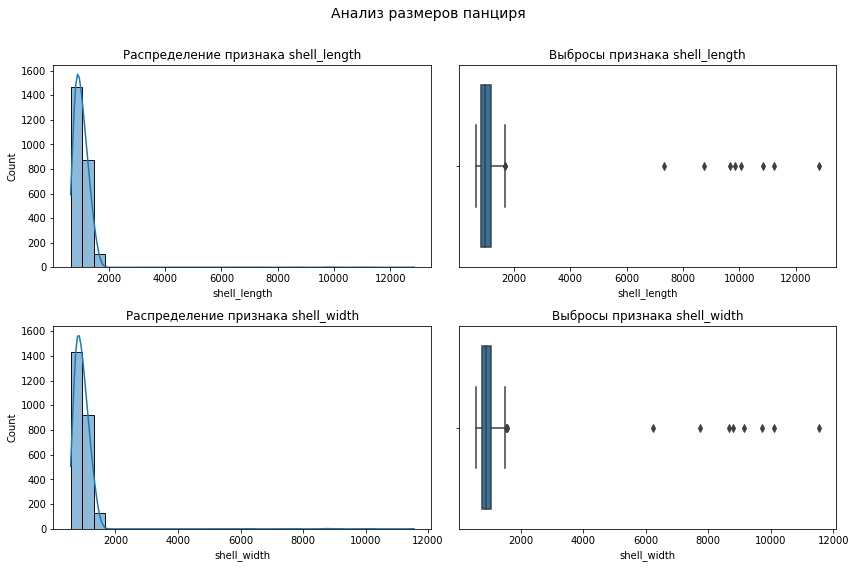

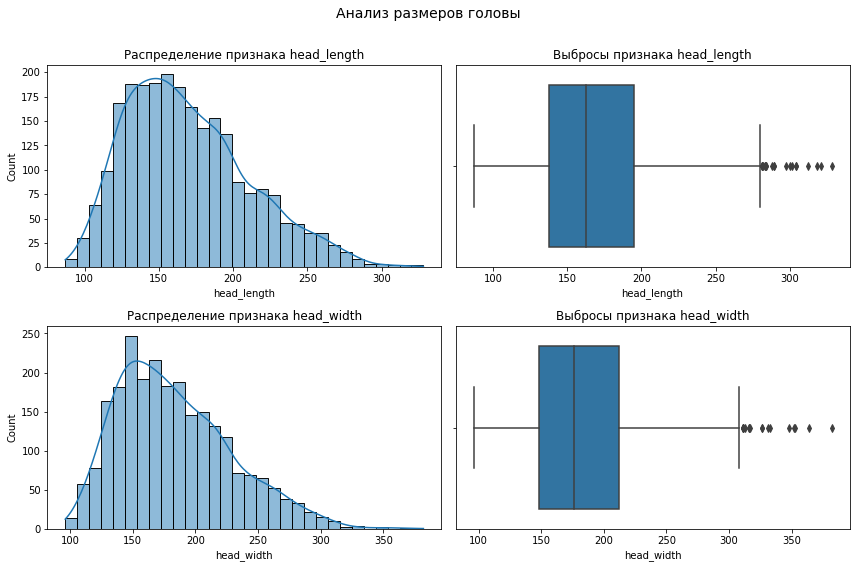

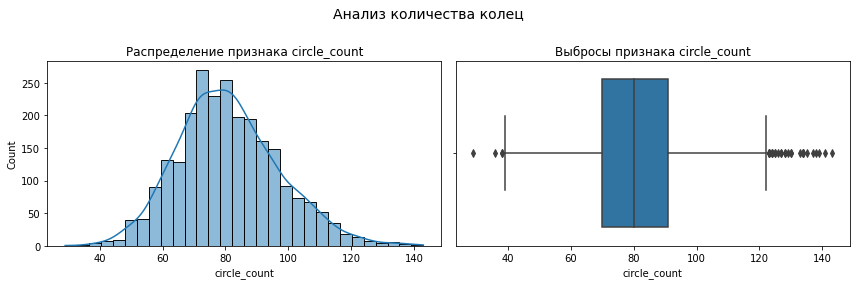

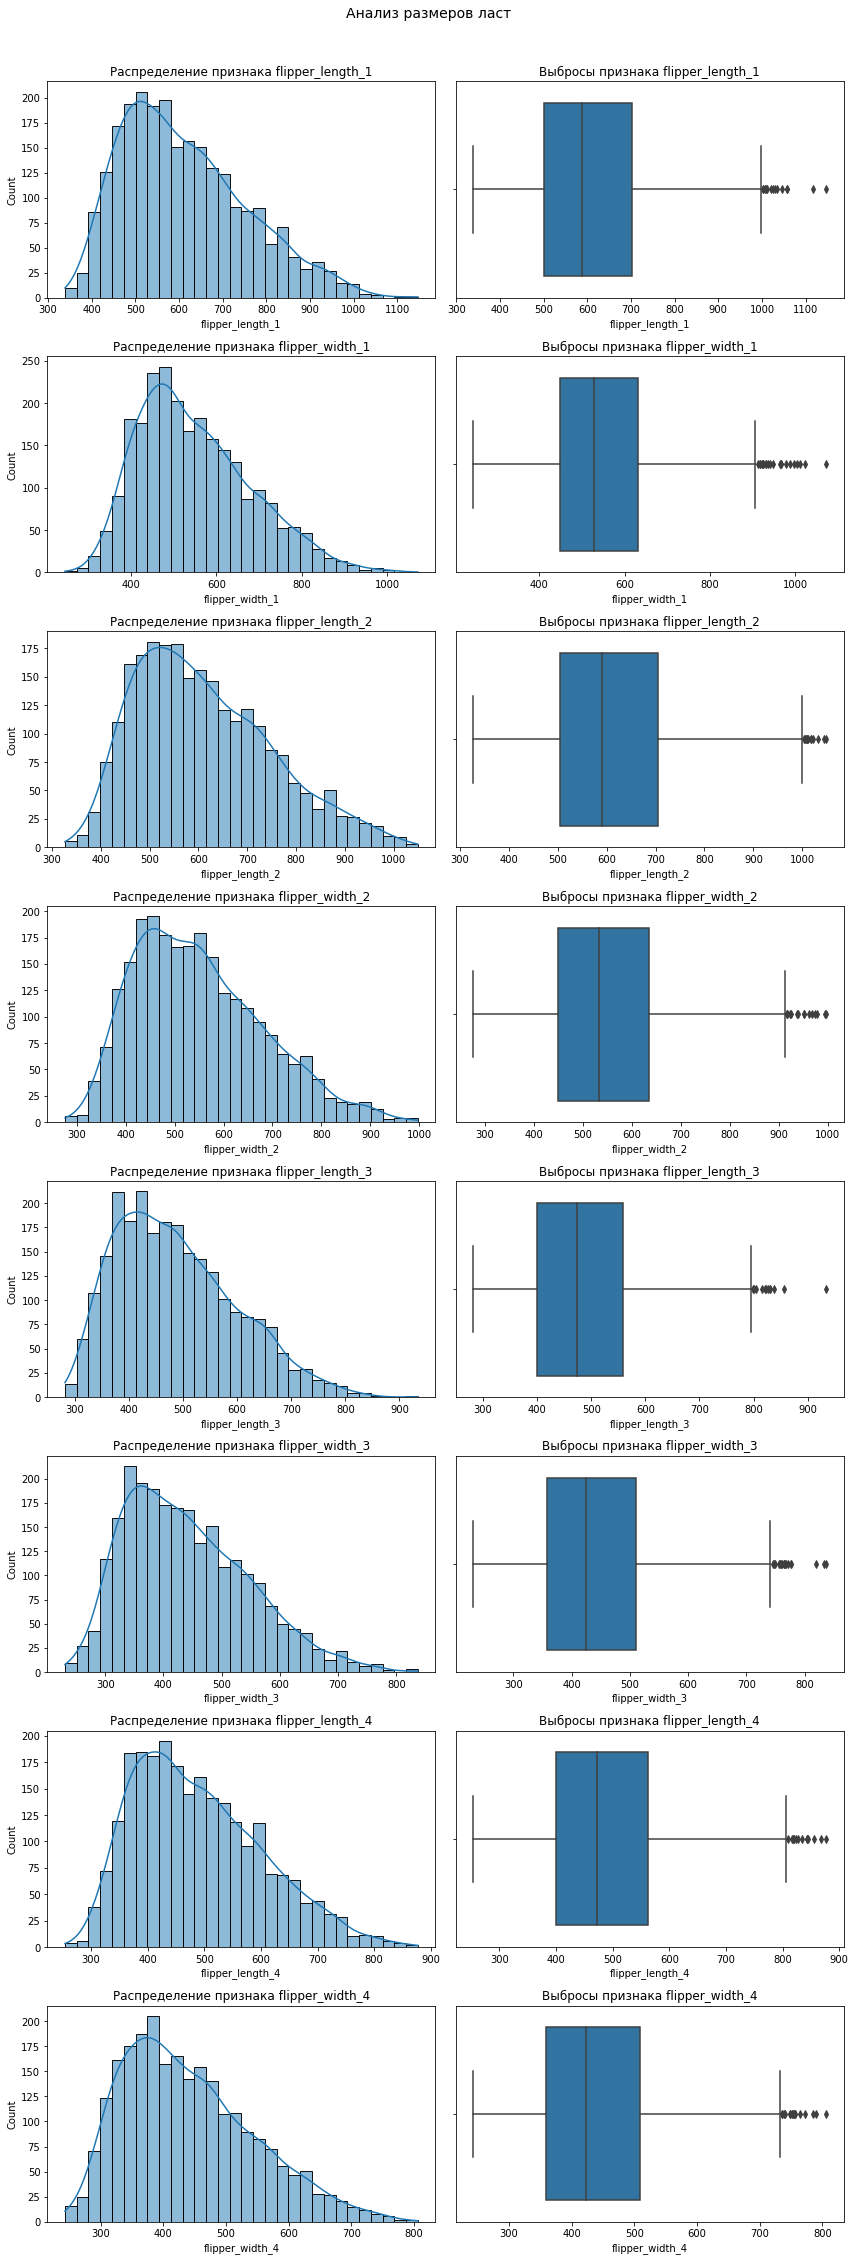

In [12]:
# Панцирь
plot_feature_group(
    df,
    ['shell_length', 'shell_width'],
    title='Анализ размеров панциря'
)

# Голова
plot_feature_group(
    df,
    ['head_length', 'head_width'],
    title='Анализ размеров головы'
)

# Кольца
plot_feature_group(
    df,
    ['circle_count'],
    title='Анализ количества колец'
)

# Ласты (далее, для избегания мультиколлинеарности, будет решено взять среднее по столбцам)
plot_feature_group(
    df,
    ['flipper_length_1',
     'flipper_width_1',
     'flipper_length_2',
     'flipper_width_2',
     'flipper_length_3',
     'flipper_width_3',
     'flipper_length_4',
     'flipper_width_4',],
    title='Анализ размеров ласт'
)

### Подвывод по графикам

По построенным графикам можно сделать несколько важных наблюдений.

1. **Признаки `shell_length` и `shell_width`** имеют основную массу значений в относительно компактной области, однако справа наблюдается группа очень крупных значений, сильно оторванных от общего распределения. На boxplot эти точки выглядят как экстремальные выбросы, а на гистограммах из-за них появляется длинный правый хвост и сильно сжимается основная часть распределения.  
   С учётом комментария заказчика это очень похоже на ошибку масштаба: часть значений длины и ширины панциря, вероятно, была ошибочно умножена на 10. Поэтому такие наблюдения не стоит сразу удалять — их разумнее проверить и, при подтверждении гипотезы, скорректировать.

2. **Признаки `head_length` и `head_width`** имеют одновершинное распределение с выраженной **правосторонней асимметрией**: основная масса значений сосредоточена в средней области, а справа тянется длинный хвост. Это означает, что среди наблюдений есть сравнительно небольшое число особей с особенно крупными размерами головы.  
   На boxplot действительно заметны отдельные выбросы, но они не выглядят столь аномальными, как в случае с размерами панциря. Они могут быть связаны с естественной биологической изменчивостью, а не с ошибкой в данных.

3. По графикам усреднённых размеров ласт и других морфометрических признаков также видно, что распределения в целом **похожи по форме**: чаще всего они одновершинные, умеренно или заметно смещены вправо, с небольшим числом крупных значений. Это логично, поскольку размеры частей тела у животных обычно не распределяются строго симметрично, а крупные особи встречаются реже.

4. **Неожиданные пики** на гистограммах, если они наблюдаются, могут быть связаны с:
   - округлением измерений;
   - особенностями процесса усреднения;
   - тем, что часть размеров чаще фиксировалась в определённых значениях;
   - смешением черепах немного разных возрастных групп внутри одной выборки.  
   Если такие пики не сопровождаются биологически невозможными значениями, сами по себе они не являются основанием для удаления данных.

In [13]:
# Количественное описание выбросов

length_cols = [
    'shell_length', 'shell_width', 'head_length', 'head_width',
    'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
    'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4'
]

display(df[length_cols].describe().T.sort_values(by='max', ascending=False))

,count,mean,std,min,25%,50%,75%,max
shell_length,2457.0,1047.963777,568.694898,645.0,837.00,980.0,1172.0,12840.0
shell_width,2486.0,945.018101,507.521189,564.0,752.25,889.0,1056.0,11550.0
flipper_length_1,2486.0,612.010459,142.589526,339.0,502.00,587.0,702.0,1147.0
flipper_width_1,2486.0,549.364441,131.859104,245.0,449.00,527.0,632.0,1072.0
flipper_length_2,2486.0,611.890185,138.991986,327.0,505.00,591.0,704.0,1049.0
flipper_width_2,2486.0,550.253017,130.856316,276.0,449.00,533.0,635.0,997.0
flipper_length_3,2457.0,487.262922,110.435270,282.0,400.00,473.0,558.0,934.0
flipper_length_4,2457.0,489.176231,112.562973,254.0,400.00,473.0,563.0,877.0
flipper_width_3,2457.0,440.667481,105.532073,231.0,357.00,425.0,511.0,837.0
flipper_width_4,2457.0,440.975173,104.573836,243.0,359.00,423.0,509.0,806.0


In [14]:
# Исправляем явно завышенные значения в 'shell_length', 'shell_width'

shell_length_mask = df['shell_length'] > df['shell_length'].median() * 3
shell_width_mask = df['shell_width'] > df['shell_width'].median() * 3

df.loc[shell_length_mask, 'shell_length'] = df.loc[shell_length_mask, 'shell_length'] / 10
df.loc[shell_width_mask, 'shell_width'] = df.loc[shell_width_mask, 'shell_width'] / 10

display(df[length_cols].describe().T.sort_values(by='max', ascending=False))

print('Исправлено значений shell_length:', shell_length_mask.sum())
print('Исправлено значений shell_width:', shell_width_mask.sum())

,count,mean,std,min,25%,50%,75%,max
shell_length,2457.0,1018.436304,222.149470,645.0,837.0,979.0,1168.0,1683.0
shell_width,2486.0,918.970233,203.241558,564.0,752.0,887.0,1054.0,1554.0
flipper_length_1,2486.0,612.010459,142.589526,339.0,502.0,587.0,702.0,1147.0
flipper_width_1,2486.0,549.364441,131.859104,245.0,449.0,527.0,632.0,1072.0
flipper_length_2,2486.0,611.890185,138.991986,327.0,505.0,591.0,704.0,1049.0
flipper_width_2,2486.0,550.253017,130.856316,276.0,449.0,533.0,635.0,997.0
flipper_length_3,2457.0,487.262922,110.435270,282.0,400.0,473.0,558.0,934.0
flipper_length_4,2457.0,489.176231,112.562973,254.0,400.0,473.0,563.0,877.0
flipper_width_3,2457.0,440.667481,105.532073,231.0,357.0,425.0,511.0,837.0
flipper_width_4,2457.0,440.975173,104.573836,243.0,359.0,423.0,509.0,806.0


Исправлено значений shell_length: 8
Исправлено значений shell_width: 8


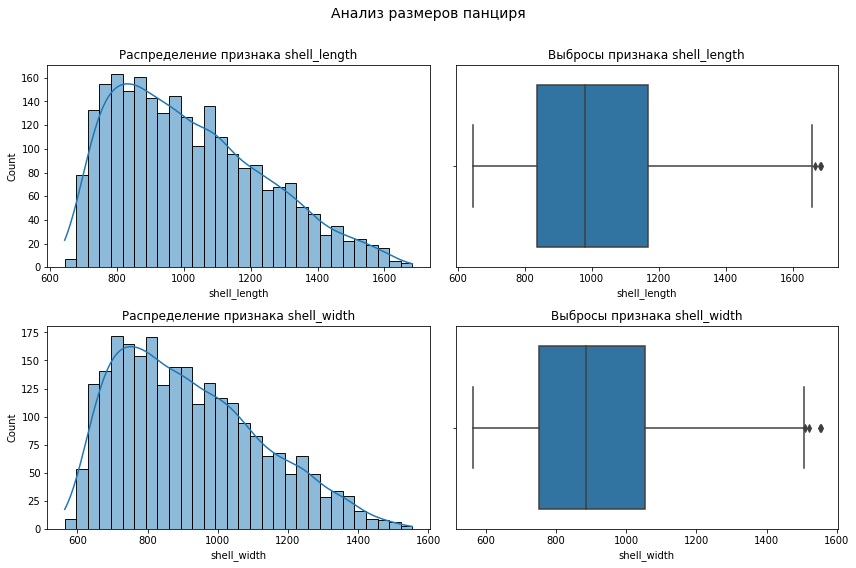

In [15]:
# Еще раз посмотрим графики

plot_feature_group(
    df,
    ['shell_length', 'shell_width'],
    title='Анализ размеров панциря'
)

### После исправления, графики, описывающие характеристики панциря, приняли значения, схожие с другими графиками - оставляем

In [16]:
# 8. Проанализируйте корреляцию между признаками и целевой переменной

corr_with_target = (
    df
    .corr()['weight']
    .sort_values(ascending=False)
    .to_frame('corr_with_weight')
)

display(corr_with_target)

,corr_with_weight
weight,1.000000
shell_length,0.978047
shell_width,0.962173
flipper_length_1,0.920193
flipper_length_4,0.919410
flipper_length_2,0.917602
flipper_length_3,0.915939
flipper_width_2,0.897546
flipper_width_4,0.896082
flipper_width_3,0.895270


In [17]:
import pandas as pd

pd.__version__

'1.2.4'

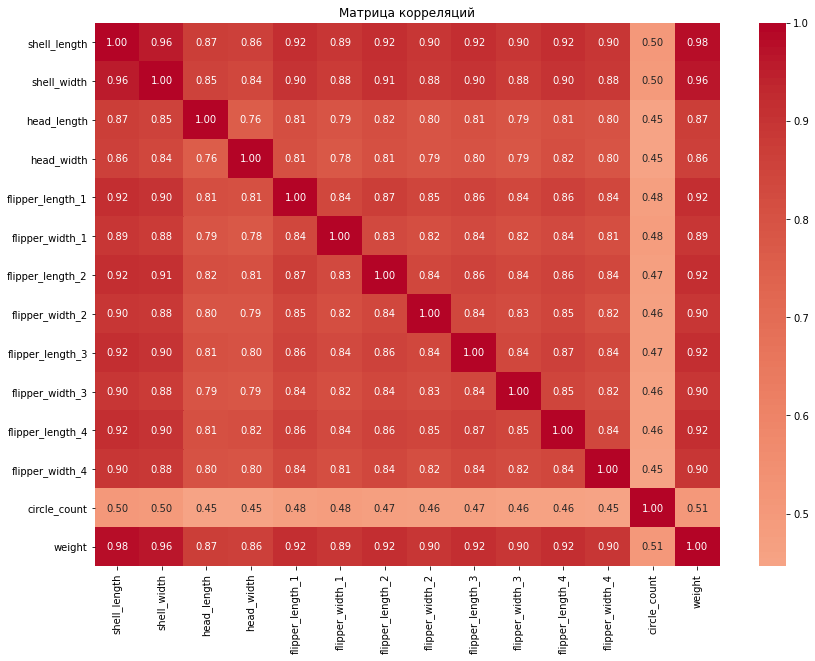

In [18]:
# Тепловая карта корреляций

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.show()

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    
**Совет на будущее: как увидеть больше связей 💡**

Ты используешь стандартный метод `.corr()`, который вычисляет коэффициент Пирсона. Для этого проекта (линейная регрессия и числовые признаки) этого вполне достаточно, всё верно.

Однако на будущее полезно знать, что коэффициент Пирсона видит только **линейные** связи. Если зависимость похожа на параболу или синусоиду, `.corr()` покажет 0, хотя связь есть.
В реальных задачах рекомендую библиотеку **`phik`** . Она умеет:

1. Находить нелинейные зависимости.
2. Строить матрицу корреляций даже для **категориальных** признаков (текстовых) без предварительного кодирования.
Попробуй как-нибудь: `import phik` -> `df.phik_matrix()`.
    
  </div>

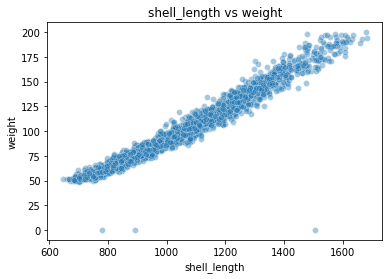

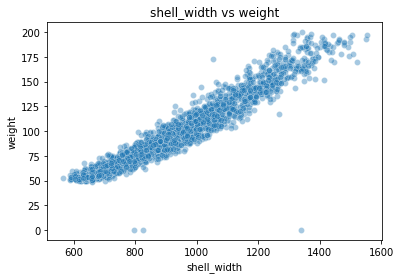

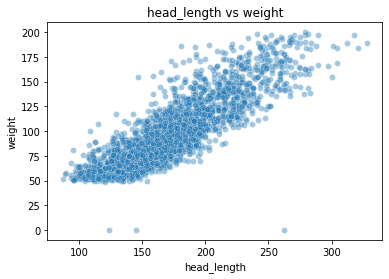

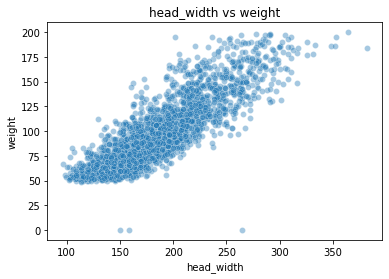

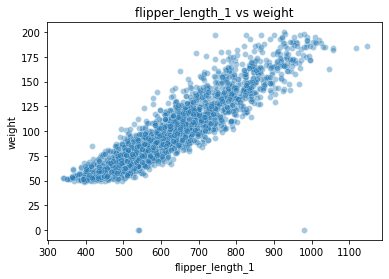

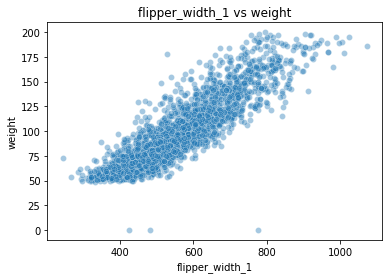

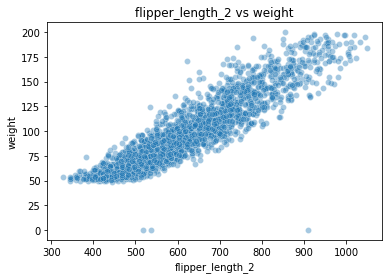

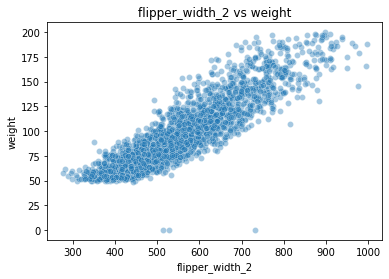

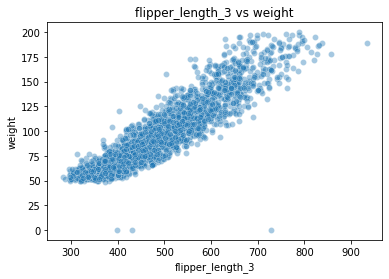

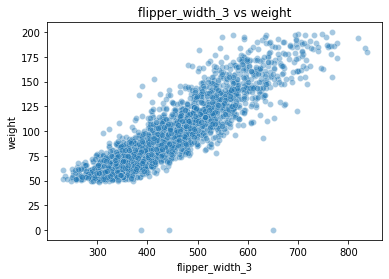

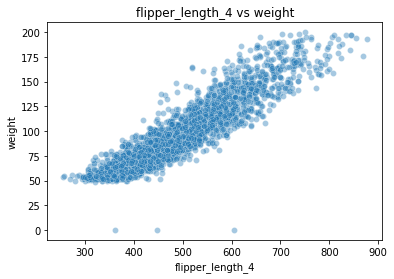

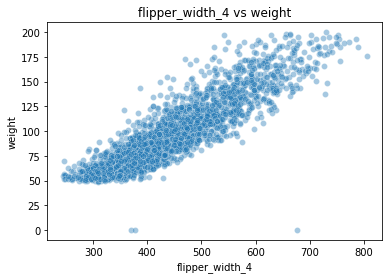

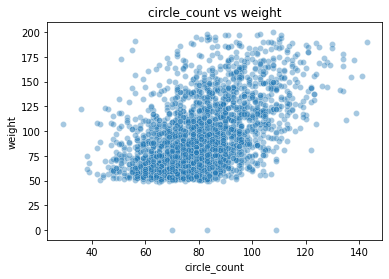

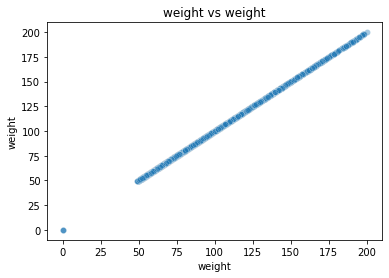

In [19]:
# Графики зависимости признаков от целевой переменной

for col in df:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y='weight', alpha=0.4)
    plt.title(f'{col} vs weight')
    plt.show()

In [20]:
# Именно тут я удалял столбец measure_count
'''
# Убираем признаки с низкой корреляцией (можно было бы убрать конкретный столбец, но делаем универсально)
low_corr_features = corr_with_target[
    (corr_with_target.index != 'weight') &
    (corr_with_target['corr_with_weight'].abs() < 0.1)
].index.tolist()

print('Признаки с очень слабой корреляцией с weight:', low_corr_features)

if low_corr_features:
    df = df.drop(columns=low_corr_features)
'''

"\n# Убираем признаки с низкой корреляцией (можно было бы убрать конкретный столбец, но делаем универсально)\nlow_corr_features = corr_with_target[\n    (corr_with_target.index != 'weight') &\n    (corr_with_target['corr_with_weight'].abs() < 0.1)\n].index.tolist()\n\nprint('Признаки с очень слабой корреляцией с weight:', low_corr_features)\n\nif low_corr_features:\n    df = df.drop(columns=low_corr_features)\n"

In [21]:
# 9. Проверьте данные на мультиколлинеарность

# Пары признаков с высокой корреляцией

feature_cols = [col for col in df.columns if col != 'weight']

feature_corr = df[feature_cols].corr().abs()

high_corr_pairs = []

for i, col1 in enumerate(feature_corr.columns):
    for j, col2 in enumerate(feature_corr.columns):
        if j > i and feature_corr.loc[col1, col2] >= 0.85:
            high_corr_pairs.append((col1, col2, feature_corr.loc[col1, col2]))

high_corr_pairs = pd.DataFrame(high_corr_pairs, columns=['feature_1', 'feature_2', 'corr'])
display(high_corr_pairs.sort_values(by='corr', ascending=False))

,feature_1,feature_2,corr
0,shell_length,shell_width,0.959996
3,shell_length,flipper_length_1,0.920130
9,shell_length,flipper_length_4,0.918971
5,shell_length,flipper_length_2,0.917355
7,shell_length,flipper_length_3,0.915656
14,shell_width,flipper_length_2,0.905552
12,shell_width,flipper_length_1,0.904319
18,shell_width,flipper_length_4,0.902691
16,shell_width,flipper_length_3,0.901921
6,shell_length,flipper_width_2,0.897790


Мультиколлинеарность можно устранять не только удалением признаков. Альтернативой является использование регуляризованных линейных моделей, например Ridge или Lasso, которые снижают нестабильность коэффициентов при сильной корреляции признаков. Также возможно объединение схожих признаков в агрегированные показатели, например расчёт средней длины и средней ширины ласт.

Тем не менее, для данного проекта удаление одного из сильно коррелирующих признаков или их агрегирование является наиболее простым и интерпретируемым решением. Такой подход облегчает анализ важности признаков и позволяет получить более устойчивую линейную модель.

In [22]:
# Стратегия не рабочая! Пробуем второй способ

'''
# Удаление одного признака из каждой пары с очень высокой корреляцией:
# удаляем тот, у которого связь с target слабее

# Абсолютная корреляция признаков с целевой переменной
target_corr = df[feature_cols + ['weight']].corr(numeric_only=True)['weight'].abs()

features_to_drop_multicol = []

for col1, col2, _ in high_corr_pairs.itertuples(index=False):
    corr1 = target_corr[col1]
    corr2 = target_corr[col2]

    if corr1 < corr2:
        features_to_drop_multicol.append(col1)
    else:
        features_to_drop_multicol.append(col2)

features_to_drop_multicol = sorted(set(features_to_drop_multicol))

print('Признаки к удалению из-за мультиколлинеарности:', features_to_drop_multicol)

if features_to_drop_multicol:
    df = df.drop(columns=features_to_drop_multicol)
'''

"\n# Удаление одного признака из каждой пары с очень высокой корреляцией:\n# удаляем тот, у которого связь с target слабее\n\n# Абсолютная корреляция признаков с целевой переменной\ntarget_corr = df[feature_cols + ['weight']].corr(numeric_only=True)['weight'].abs()\n\nfeatures_to_drop_multicol = []\n\nfor col1, col2, _ in high_corr_pairs.itertuples(index=False):\n    corr1 = target_corr[col1]\n    corr2 = target_corr[col2]\n\n    if corr1 < corr2:\n        features_to_drop_multicol.append(col1)\n    else:\n        features_to_drop_multicol.append(col2)\n\nfeatures_to_drop_multicol = sorted(set(features_to_drop_multicol))\n\nprint('Признаки к удалению из-за мультиколлинеарности:', features_to_drop_multicol)\n\nif features_to_drop_multicol:\n    df = df.drop(columns=features_to_drop_multicol)\n"

In [23]:
# Списки столбцов с размерами ласт
flipper_length_cols = ['flipper_length_1', 'flipper_length_2', 'flipper_length_3', 'flipper_length_4']
flipper_width_cols = ['flipper_width_1', 'flipper_width_2', 'flipper_width_3', 'flipper_width_4']

# Создаём агрегированные признаки
df['flipper_length_mean'] = df[flipper_length_cols].mean(axis=1)
df['flipper_width_mean'] = df[flipper_width_cols].mean(axis=1)

# Оставляем нужные признаки
columns_to_keep = [
    'shell_length',
    'shell_width',
    'head_length',
    'head_width',
    'circle_count',
    'flipper_length_mean',
    'flipper_width_mean',
    'weight'
]

df = df[columns_to_keep].copy()

print('Итоговые признаки:')
print(df.columns.tolist())
df.info()

Итоговые признаки:
['shell_length', 'shell_width', 'head_length', 'head_width', 'circle_count', 'flipper_length_mean', 'flipper_width_mean', 'weight']
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2486 entries, 8 to 7840
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   shell_length         2457 non-null   float64
 1   shell_width          2486 non-null   float64
 2   head_length          2451 non-null   float64
 3   head_width           2451 non-null   float64
 4   circle_count         2486 non-null   int64  
 5   flipper_length_mean  2486 non-null   float64
 6   flipper_width_mean   2486 non-null   float64
 7   weight               2486 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 174.8 KB


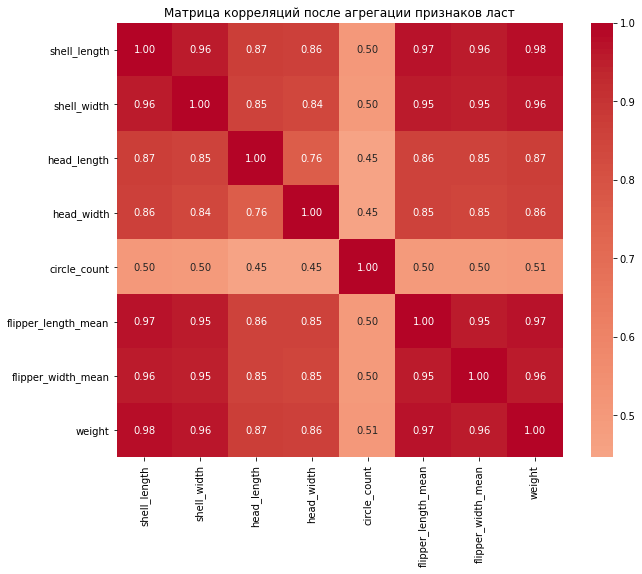

In [24]:
# Повторная проверка корреляции

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций после агрегации признаков ласт')
plt.show()

In [25]:
# Отдельно корреляция признаков с целевой переменной - оставляем так

corr_with_target = corr_matrix['weight'].sort_values(ascending=False)
display(corr_with_target)

weight                 1.000000
shell_length           0.978047
flipper_length_mean    0.968342
shell_width            0.962173
flipper_width_mean     0.960773
head_length            0.869587
head_width             0.863186
circle_count           0.506291
Name: weight, dtype: float64

In [26]:
# Финальная версия датафрейма после EDA

df_model = df.copy()

# Убираем нулевые значения (обжегся при обучении модели)
df_model = df_model[df_model['weight'] > 0].copy()

print('Размер итогового датафрейма для моделирования:', df_model.shape)
print('Итоговые признаки:')
print(df_model.columns.tolist())
display(df_model.head())

Размер итогового датафрейма для моделирования: (2483, 8)
Итоговые признаки:
['shell_length', 'shell_width', 'head_length', 'head_width', 'circle_count', 'flipper_length_mean', 'flipper_width_mean', 'weight']


,shell_length,shell_width,head_length,head_width,circle_count,flipper_length_mean,flipper_width_mean,weight
8,742.0,652.0,118.0,147.0,66,410.75,367.00,56.352
11,1336.0,1318.0,207.0,248.0,111,688.50,685.75,154.074
16,1010.0,926.0,216.0,156.0,76,527.75,454.25,87.695
20,703.0,606.0,NaN,NaN,62,345.50,340.00,51.182
21,982.0,940.0,187.0,157.0,103,525.25,502.50,92.707


### <span style="color: turquoise;">Подвывод</span>

В ходе исследовательского анализа данных были выполнены отбор целевой популяции и первичная подготовка признаков для моделирования. Из исходного датасета были оставлены только записи о черепахах вида **Chelonia mydas**, поскольку именно для этого вида требуется построить модель прогнозирования массы.

Далее были исключены признаки, не несущие полезной информации для обучения модели, а также проведена работа по снижению мультиколлинеарности. Вместо отдельных признаков, описывающих размеры каждой из четырёх ласт, были сформированы агрегированные показатели:
- `flipper_length_mean` — средняя длина ласт;
- `flipper_width_mean` — средняя ширина ласт.

Такой подход позволил сократить число сильно коррелирующих между собой признаков и при этом сохранить основную информацию о размерах конечностей.

В результате был сформирован итоговый датафрейм для моделирования размером **2483 × 8**. В него вошли следующие признаки:
- `shell_length`,
- `shell_width`,
- `head_length`,
- `head_width`,
- `circle_count`,
- `flipper_length_mean`,
- `flipper_width_mean`,
- `weight`.

Таким образом, на текущем этапе удалось получить компактный и содержательный набор признаков, который можно использовать для дальнейшей предобработки, разделения на выборки и обучения линейных моделей.

## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

In [27]:
# 1.

X = df_model.drop(columns='weight')
y = df_model['weight']

# Выделите на train_val и test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y,
                                                    test_size=0.2,
													shuffle=True,
                                                    random_state=RANDOM_STATE)

# Выделите на train и val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                    test_size=0.25,
													shuffle=True,
                                                    random_state=RANDOM_STATE)

In [28]:
# 2.

# Смотрии пропуски - видим, что значения пропущены только в 3 столбцах,
# Будем заменять медианным значением обучающей выборки

print(X_train.isna().sum())
print()
print(X_val.isna().sum())
print()
print(X_test.isna().sum())
print()

print(y_train.isna().sum())
print()
print(y_val.isna().sum())
print()
print(y_test.isna().sum())

shell_length           14
shell_width             0
head_length            22
head_width             22
circle_count            0
flipper_length_mean     0
flipper_width_mean      0
dtype: int64

shell_length           10
shell_width             0
head_length             8
head_width              8
circle_count            0
flipper_length_mean     0
flipper_width_mean      0
dtype: int64

shell_length           5
shell_width            0
head_length            5
head_width             5
circle_count           0
flipper_length_mean    0
flipper_width_mean     0
dtype: int64

0

0

0


In [29]:
def fill_missing_with_train_median(X_train, X_val, X_test):
    train_medians = X_train.median()

    X_train_filled = X_train.fillna(train_medians)
    X_val_filled = X_val.fillna(train_medians)
    X_test_filled = X_test.fillna(train_medians)

    return X_train_filled, X_val_filled, X_test_filled

X_train_raw, X_val_raw, X_test_raw = fill_missing_with_train_median(X_train, X_val, X_test)

print(X_train_raw.isna().sum().sum())
print()
print(X_val_raw.isna().sum().sum())
print()
print(X_test_raw.isna().sum().sum())

0

0

0


In [30]:
# 3, 4.

# Масштабирование
def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std()
        X_train_scaled = (X_train - mean) / std
        X_val_scaled = (X_val - mean) / std
        X_test_scaled = (X_test - mean) / std
    elif method == 'minmax':
        min_val = X_train.min()
        max_val = X_train.max()
        X_train_scaled = (X_train - min_val) / (max_val - min_val)
        X_val_scaled = (X_val - min_val) / (max_val - min_val)
        X_test_scaled = (X_test - min_val) / (max_val - min_val)
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")
    return X_train_scaled, X_val_scaled, X_test_scaled

X_train_std, X_val_std, X_test_std = scale_data(X_train_raw, X_val_raw, X_test_raw, method='standard')

X_train_norm, X_val_norm, X_test_norm = scale_data(X_train_raw, X_val_raw, X_test_raw, method='minmax')

In [31]:
# 5.

datasets = {
    'raw': (X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test),
    'standardized': (X_train_std, X_val_std, X_test_std, y_train, y_val, y_test),
    'normalized': (X_train_norm, X_val_norm, X_test_norm, y_train, y_val, y_test)
}

### <span style="color: turquoise;">Подвывод</span>

Данные были разделены на обучающую, валидационную и тестовую выборки в соотношении 60:20:20. Такое разбиение позволяет обучать модель, подбирать её параметры на валидационной выборке и выполнять финальную оценку качества на тестовой выборке.

Пропуски в признаках были заполнены медианными значениями. Для предотвращения утечки данных медианы рассчитывались только по обучающей выборке, после чего использовались для заполнения пропусков в обучающей, валидационной и тестовой выборках.

Для дальнейшего сравнения моделей были подготовлены три варианта наборов данных:
- без масштабирования;
- со стандартизацией признаков;
- с нормализацией признаков.

Параметры стандартизации и нормализации также рассчитывались только по обучающей выборке, что соответствует правилам корректной предобработки данных.

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

In [32]:
# Расчёт метрик
def calculate_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }

In [33]:
# 1. Строим Дамми

def create_dummy_model(y_train):
    return y_train.mean()

def dummy_regressor_predict(dummy_model, X):
    return np.repeat(dummy_model, len(X))

In [34]:
# 2. Функция для обучения и оценки модели

def train_model(model, model_name, dataset_name, X_train, y_train):
    model.fit(X_train, y_train)

    return {
        'model_name': model_name,
        'dataset_name': dataset_name,
        'model': model
    }

In [35]:
# 3. Обучение нескольких линейных моделей только на train

trained_models = []

for dataset_name, (X_train_cur, X_val_cur, X_test_cur, y_train_cur, y_val_cur, y_test_cur) in datasets.items():

    # Дамми-модель
    dummy_model = create_dummy_model(y_train_cur)
    trained_models.append({
        'model_name': 'DummyRegressor_mean',
        'dataset_name': dataset_name,
        'model': dummy_model
    })

    # LinearRegression
    lr_model = LinearRegression()
    trained_models.append(
        train_model(
            lr_model, 'LinearRegression', dataset_name,
            X_train_cur, y_train_cur
        )
    )

    # Lasso
    for alpha in [0.01, 0.1]:
        lasso_model = Lasso(alpha=alpha, max_iter=1000, random_state=RANDOM_STATE)
        trained_models.append(
            train_model(
                lasso_model, f'Lasso_alpha={alpha}', dataset_name,
                X_train_cur, y_train_cur
            )
        )

    # Ridge
    for alpha in [0.1, 1.0]:
        ridge_model = Ridge(alpha=alpha, random_state=RANDOM_STATE)
        trained_models.append(
            train_model(
                ridge_model, f'Ridge_alpha={alpha}', dataset_name,
                X_train_cur, y_train_cur
            )
        )

    # SGDRegressor
    for loss in ['squared_loss', 'epsilon_insensitive']:
        sgd_model = SGDRegressor(
            loss=loss,
            penalty='l2',
            alpha=0.01,
            max_iter=1000,
            tol=1e-2,
            random_state=RANDOM_STATE
        )
        trained_models.append(
            train_model(
                sgd_model, f'SGDRegressor_loss={loss}', dataset_name,
                X_train_cur, y_train_cur
            )
        )

trained_models_df = pd.DataFrame(trained_models)[['model_name', 'dataset_name']]
display(trained_models_df)

,model_name,dataset_name
0,DummyRegressor_mean,raw
1,LinearRegression,raw
2,Lasso_alpha=0.01,raw
3,Lasso_alpha=0.1,raw
4,Ridge_alpha=0.1,raw
5,Ridge_alpha=1.0,raw
6,SGDRegressor_loss=squared_loss,raw
7,SGDRegressor_loss=epsilon_insensitive,raw
8,DummyRegressor_mean,standardized
9,LinearRegression,standardized


In [36]:
# Оценка обученных моделей на валидационной выборке

validation_results = []

for trained_model in trained_models:
    model_name = trained_model['model_name']
    dataset_name = trained_model['dataset_name']
    model = trained_model['model']

    X_train_cur, X_val_cur, X_test_cur, y_train_cur, y_val_cur, y_test_cur = datasets[dataset_name]

    if model_name == 'DummyRegressor_mean':
        y_pred = dummy_regressor_predict(model, X_val_cur)
    else:
        y_pred = model.predict(X_val_cur)

    metrics = calculate_metrics(y_val_cur, y_pred)

    validation_results.append({
        'model_name': model_name,
        'dataset_name': dataset_name,
        **metrics
    })

validation_results_df = pd.DataFrame(validation_results)
validation_results_df = validation_results_df.sort_values(by='MAE').reset_index(drop=True)

display(validation_results_df.round(4))

,model_name,dataset_name,MAE,MSE,R2,MAPE
0,Ridge_alpha=1.0,normalized,3.865800e+00,2.541980e+01,9.806000e-01,4.200000e-02
1,Lasso_alpha=0.1,standardized,3.866600e+00,2.538280e+01,9.806000e-01,4.200000e-02
2,Ridge_alpha=0.1,normalized,3.867400e+00,2.527550e+01,9.807000e-01,4.220000e-02
3,Lasso_alpha=0.01,normalized,3.867700e+00,2.533640e+01,9.807000e-01,4.210000e-02
4,Lasso_alpha=0.01,standardized,3.867700e+00,2.527500e+01,9.807000e-01,4.220000e-02
5,Ridge_alpha=1.0,standardized,3.867800e+00,2.526790e+01,9.807000e-01,4.220000e-02
6,Ridge_alpha=0.1,standardized,3.867900e+00,2.526660e+01,9.807000e-01,4.220000e-02
7,LinearRegression,standardized,3.867900e+00,2.526650e+01,9.807000e-01,4.220000e-02
8,LinearRegression,normalized,3.867900e+00,2.526650e+01,9.807000e-01,4.220000e-02
9,LinearRegression,raw,3.867900e+00,2.526650e+01,9.807000e-01,4.220000e-02


### <span style="color: turquoise;">Подвывод</span>

Для удобства сравнения всех обученных моделей была сформирована итоговая таблица в формате DataFrame. В неё включены:
- название модели;
- название датасета с указанием способа масштабирования признаков;
- метрики качества на валидационной выборке: `MAE`, `MSE`, `R²`, `MAPE`.

Основной метрикой при сравнении моделей выбрана `MAE`, поскольку именно она показывает среднюю абсолютную ошибку предсказания массы в килограммах. Дополнительно были использованы:
- `MSE` — для оценки средней квадратичной ошибки;
- `R²` — для оценки доли объяснённой дисперсии;
- `MAPE` — для анализа относительной ошибки модели.

Таблица результатов позволяет выбрать лучшую модель по совокупности метрик и затем проверить её качество на тестовой выборке.

## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

## <span style="color: turquoise;">Результаты сравнения</span>

Для сравнения моделей использовались метрики **MAE**, **MSE**, **R²** и **MAPE** на валидационной выборке. Основной метрикой выбрана **MAE**, так как по условию проекта именно она показывает среднюю абсолютную ошибку предсказания массы в килограммах.

### Сравнение с базовой моделью

Базовая дамми-модель, которая всегда предсказывает среднее значение массы по обучающей выборке, показала слабый результат:
- **MAE = 29.3529**
- **MSE = 1314.588**
- **R² = -0.0029**
- **MAPE = 0.3244**

Лучшие линейные модели показали значительно более высокое качество. Например, лучшая модель на валидационной выборке имеет:
- **MAE = 3.8658**
- **MSE = 25.4198**
- **R² = 0.9806**
- **MAPE = 0.0420**

Таким образом, по сравнению с базовой моделью:
- средняя абсолютная ошибка уменьшилась на **25.5 кг**;
- относительное улучшение по MAE составило примерно **86.8%**;
- коэффициент детерминации вырос с отрицательного значения до **0.98**, то есть модель стала объяснять почти всю вариативность целевой переменной.

Следовательно, результат базовой модели удалось **существенно улучшить**.

### Выбор лучшей модели

По основной метрике **MAE** лучшей оказалась модель:

- **Ridge_alpha=1.0**
- датасет: **normalized**
- **MAE = 3.8658**

Несмотря на то что несколько моделей показали очень близкие результаты, именно эта конфигурация дала минимальное значение MAE на валидационной выборке. Поэтому её следует выбрать как лучшую для дальнейшей итоговой проверки.

### Вывод

Лучшее качество на валидационной выборке показали модели **LinearRegression**, **Ridge** и **Lasso**. Их результаты оказались очень близкими, что говорит о высокой устойчивости линейного подхода для данной задачи. При этом модели `SGDRegressor` в большинстве конфигураций показали более слабые результаты, а на данных без масштабирования — нестабильную работу.

Наилучшей моделью по основной метрике **MAE** стала **Ridge-регрессия с параметром `alpha=1.0` на нормализованных данных**. Именно эту модель следует далее проверить на **тестовой выборке** для окончательной оценки качества и принятия решения о возможности внедрения.

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

In [37]:
best_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
best_model.fit(X_train_norm, y_train)

y_train_pred = best_model.predict(X_train_norm)
y_val_pred = best_model.predict(X_val_norm)
y_test_pred = best_model.predict(X_test_norm)
            

In [38]:
# Метрики на обучающей, валидационной и тестовой выборках
train_metrics = calculate_metrics(y_train, y_train_pred)
val_metrics = calculate_metrics(y_val, y_val_pred)
test_metrics = calculate_metrics(y_test, y_test_pred)

metrics_comparison = pd.DataFrame(
    [train_metrics, val_metrics, test_metrics],
    index=['train', 'validation', 'test']
)

metrics_comparison['MAPE_percent'] = metrics_comparison['MAPE'] * 100

display(metrics_comparison.round(4))

,MAE,MSE,R2,MAPE,MAPE_percent
train,3.7019,23.9141,0.9802,0.0409,4.0873
validation,3.8658,25.4198,0.9806,0.0420,4.1989
test,3.7711,25.1348,0.9789,0.0404,4.0445


In [39]:
# Проверка требований заказчика
mae_ok = test_metrics['MAE'] <= 5
r2_ok = test_metrics['R2'] >= 0.97

print('Соответствие требованиям заказчика:')
print(f"MAE <= 5: {mae_ok}")
print(f"R2 >= 0.97: {r2_ok}")

Соответствие требованиям заказчика:
MAE <= 5: True
R2 >= 0.97: True


## <span style="color: turquoise;">Вывод по лучшей модели</span>

Для итоговой проверки была выбрана лучшая модель по результатам валидации — **Ridge-регрессия с параметром `alpha=1.0`**, обученная на нормализованных данных.

После обучения модели на обучающей выборке были рассчитаны метрики качества на обучающей, валидационной и тестовой выборках. Это позволило не только оценить итоговое качество модели на тесте, но и проверить наличие признаков переобучения.

### Оценка качества на тестовой выборке

На тестовой выборке были рассчитаны метрики:
- **MAE** — основная метрика качества;
- **MSE** — средняя квадратичная ошибка;
- **R²** — коэффициент детерминации;
- **MAPE** — средняя относительная ошибка.

### Проверка на переобучение

Признаки переобучения можно заподозрить в том случае, если модель показывает значительно лучшее качество на обучающей выборке, чем на валидационной и тестовой. Если же значения метрик на `train`, `validation` и `test` близки друг к другу, то модель можно считать устойчивой и хорошо обобщающей данные.

### Соответствие требованиям заказчика

Модель соответствует требованиям заказчика, если на тестовой выборке:
- **MAE не превышает 5 кг**;
- **R² не ниже 0.97**.

Если эти условия выполняются, модель можно рекомендовать к внедрению, поскольку она обеспечивает высокую точность предсказания массы черепах и удовлетворяет поставленным критериям качества.

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

In [40]:
# 1. Оценка важности признаков по абсолютным значениям коэффициентов лучшей модели

feature_importance = pd.DataFrame({
    'feature': X_train_norm.columns,
    'coefficient': best_model.coef_
})

feature_importance = feature_importance.sort_values(by='coefficient', ascending=False).reset_index(drop=True)

display(feature_importance)

,feature,coefficient
0,shell_length,44.484369
1,flipper_length_mean,42.002203
2,shell_width,36.289880
3,flipper_width_mean,31.249331
4,head_length,11.527036
5,head_width,10.824209
6,circle_count,2.724962


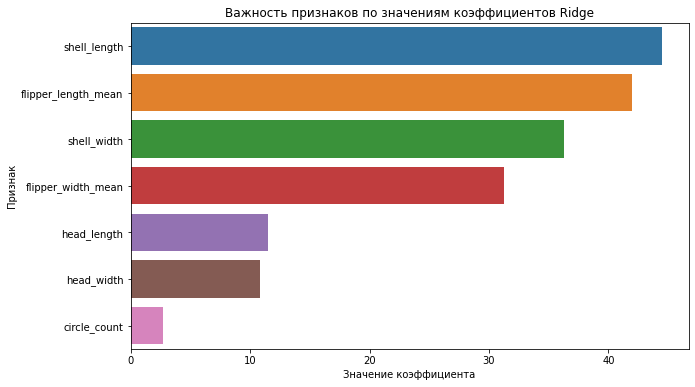

In [41]:
# Визуализация важности признаков

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='coefficient', y='feature')
plt.title('Важность признаков по значениям коэффициентов Ridge')
plt.xlabel('Значение коэффициента')
plt.ylabel('Признак')
plt.show()

#### <span style="color: turquoise;">Важнейшими признаками оказались: Длина панциря, Средняя Длина ласты и Ширина панциря. Наименее значительными признаками оказались: Длина и Ширина головы, а также Количество колец роста на панцире</span>

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

In [42]:
# Сохраняем порядок признаков, коэффициенты и параметры нормализации

feature_names = X_train_norm.columns.tolist()

coef = pd.Series(best_model.coef_, index=feature_names)
intercept = best_model.intercept_

train_min = X_train_raw[feature_names].min()
train_max = X_train_raw[feature_names].max()

In [43]:
def predict_turtle_weight(
    shell_length,
    shell_width,
    head_length,
    head_width,
    circle_count,
    flipper_length_mean,
    flipper_width_mean
):
    features = pd.Series({
        'shell_length': shell_length,
        'shell_width': shell_width,
        'head_length': head_length,
        'head_width': head_width,
        'circle_count': circle_count,
        'flipper_length_mean': flipper_length_mean,
        'flipper_width_mean': flipper_width_mean
    })

    denominator = train_max - train_min
    denominator = denominator.replace(0, 1)

    features_norm = (features - train_min) / denominator
    predicted_weight = intercept + (coef * features_norm).sum()

    return predicted_weight

In [44]:
# Пример использования

predicted_weight = predict_turtle_weight(
    shell_length=742.0,
    shell_width=652.0,
    head_length=118.0,
    head_width=147.0,
    circle_count=66,
    flipper_length_mean=410.75,
    flipper_width_mean=367.00
)

print(f'Предсказанная масса черепахи: {predicted_weight:.3f} кг')

Предсказанная масса черепахи: 53.220 кг


## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.

# <span style="color: turquoise;">Выводы и рекомендации</span>

В ходе проекта была решена задача регрессии: по морфометрическим признакам черепахи требовалось предсказывать её массу. Для работы были отобраны только данные по виду **Chelonia mydas**, после чего была проведена предобработка, устранение части проблем с мультиколлинеарностью и подготовка нескольких вариантов датасета: без масштабирования, со стандартизацией и с нормализацией.

### Какие модели были изучены

В работе были рассмотрены следующие модели:
- базовая дамми-модель, предсказывающая среднее значение целевой переменной;
- `LinearRegression`;
- `Lasso` с L1-регуляризацией;
- `Ridge` с L2-регуляризацией;
- `SGDRegressor` с разными функциями потерь.

Кроме того, сравнивались разные способы подготовки признаков:
- без масштабирования;
- стандартизация;
- нормализация.

### Какие результаты были получены

Базовая модель показала низкое качество:
- **MAE = 29.3529**
- **MSE = 1314.588**
- **R² = -0.0029**
- **MAPE = 0.3244**

Все лучшие линейные модели значительно превзошли базовый результат. На валидационной выборке лучшие конфигурации дали ошибку около **3.87 кг**, что намного лучше дамми-модели.

Лучшая модель по основной метрике **MAE** на валидационной выборке:
- **`Ridge(alpha=1.0)`**
- датасет: **normalized**
- **MAE = 3.8658**
- **MSE = 25.4198**
- **R² = 0.9806**
- **MAPE = 0.0420**

Таким образом, по сравнению с базовой моделью средняя абсолютная ошибка уменьшилась примерно на **25.5 кг**, а коэффициент детерминации вырос почти до **0.98**.

### Какая архитектура и способ обработки признаков показали себя лучше всего

Лучший результат показала модель **Ridge-регрессии** на **нормализованных признаках**.  
Именно эта комбинация оказалась наиболее удачной по основной метрике `MAE`.

При этом обычная линейная регрессия, а также `Lasso` и `Ridge` в целом показали очень близкие результаты. Это говорит о том, что задача хорошо решается линейными методами.  
`SGDRegressor` оказался заметно чувствителен к масштабу признаков: на сырых данных он работал нестабильно и в ряде конфигураций давал очень плохие результаты.

### Рекомендуется ли итоговая модель к внедрению

По результатам **валидационной выборки** модель `Ridge(alpha=1.0)` на нормализованных данных выглядит как удачное решение и **предварительно может быть рекомендована** как основной кандидат на внедрение.

Однако окончательную рекомендацию корректно давать **только после подтверждения качества на тестовой выборке**. Если на тесте модель сохранит:
- **MAE не выше 5 кг**;
- **R² не ниже 0.97**,

то её можно считать соответствующей требованиям заказчика и рекомендовать к практическому использованию.

### Какие признаки наиболее важны для модели

Наиболее важными для модели являются признаки, описывающие **общие размеры тела черепахи**:
- `shell_length`,
- `shell_width`,
- `flipper_length_mean`,
- `flipper_width_mean`.

Также вклад в предсказание вносят:
- `head_length`,
- `head_width`,
- `circle_count`.

Такой результат выглядит логичным. Масса животного напрямую связана с его габаритами, поэтому именно линейные размеры панциря, головы и ласт должны сильнее всего влиять на прогноз. Признак `circle_count` также полезен, так как косвенно связан с возрастом особи, а значит и с её размером и массой, хотя обычно его вклад ниже, чем у прямых морфометрических измерений.

### Есть ли перспективы у обучения моделей для других видов черепах

Да, такие перспективы есть. Подход в целом показал, что массу черепах можно достаточно точно оценивать по морфометрическим признакам с помощью линейных моделей. Это значит, что:
- можно обучать **отдельные модели для каждого вида**;
- либо, если данных станет достаточно много, можно строить **единую модель** с добавлением категориального признака вида.

На практике более надёжным выглядит первый путь: разные виды черепах могут заметно отличаться по пропорциям тела, поэтому отдельные модели для кожистой черепахи, биссы, логгерхеда и других видов могут дать более устойчивый результат.

### Рекомендации по дальнейшему развитию проекта

Для дальнейшего развития проекта можно предложить следующее:

1. **Проверить лучшую модель на тестовой выборке** и зафиксировать итоговые метрики как основание для окончательного вывода.
2. **Улучшить очистку данных**, особенно в части аномалий измерений, связанных с ошибочным умножением некоторых значений на 10.
3. **Собирать больше данных** по `Chelonia mydas`, чтобы повысить устойчивость модели и снизить влияние шумных наблюдений.
4. **Подготовить отдельные датасеты по другим видам** и проверить, можно ли достичь сопоставимого качества для них.
5. **Исследовать новые признаки**, например площади или произведения длины и ширины отдельных частей тела, а также отношения размеров.
6. **Автоматизировать весь пайплайн**: очистку, обработку пропусков, масштабирование и применение формулы предсказания в составе одного воспроизводимого решения.
7. **Проверить устойчивость модели на новых партиях данных**, полученных в других условиях измерения, чтобы убедиться, что она хорошо работает не только на исходной выборке.

### Итог

Проект показал, что задача бесконтактного прогнозирования массы морской черепахи по её измерениям **успешно решается линейными моделями**. Лучший результат на валидации показала **Ridge-регрессия на нормализованных признаках**. Полученные метрики указывают на высокое качество модели и на её практическую применимость. После подтверждения результатов на тестовой выборке такую модель можно рассматривать как реальный кандидат для внедрения в систему TurtleCV.

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
  
**Образцовое резюме проекта 👍**

В итоговом выводе содержатся ответы на все ключевые вопросы заказчика.
Четко обозначено, какая архитектура победила, приведены финальные цифры метрик (MAE/R2) и дана аргументированная рекомендация к внедрению модели в продакшен. Такая структура заключения показывает профессиональный подход к аналитике: от сырых данных к конкретному бизнес-решению.

</div>